In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [3]:
df.shape

(3557, 18)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,breez global hill view,sohna road,0.30,5128.0,2,2,1,11.0,New Property,650.0,0,0,0,0,0,1,91.0
1,flat,aipl club residences,sector 70a,0.95,10215.0,2,2,1,11.0,New Property,930.0,0,0,0,0,0,2,103.0
2,house,nirvana cedar crest,sector 50,7.10,32870.0,5,4,3,2.0,Moderately Old,2160.0,1,0,1,1,0,2,110.0
3,house,independent,sector 25,13.50,37313.0,5,6,3+,4.0,Old Property,3618.0,0,0,0,0,1,2,79.0
4,house,independent,sector 50,10.56,32593.0,5,5,3,3.0,Moderately Old,3240.0,0,1,0,0,0,1,20.0


In [5]:
latlong = pd.read_csv('latlong.csv')

In [6]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [7]:
latlong.insert(loc=2, column='latitude', value=latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float'))


In [8]:
latlong.insert(loc=3,column='longitude',value=latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float'))

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3287 non-null   object 
 1   society          3287 non-null   object 
 2   sector           3287 non-null   object 
 3   price            3287 non-null   float64
 4   price_per_sqft   3287 non-null   float64
 5   bedRoom          3287 non-null   int64  
 6   bathroom         3287 non-null   int64  
 7   balcony          3287 non-null   object 
 8   floorNum         3287 non-null   float64
 9   agePossession    3287 non-null   object 
 10  built_up_area    3287 non-null   float64
 11  study room       3287 non-null   int64  
 12  servant room     3287 non-null   int64  
 13  store room       3287 non-null   int64  
 14  pooja room       3287 non-null   int64  
 15  others           3287 non-null   int64  
 16  furnishing_type  3287 non-null   int64  
 17  luxury_score  

In [23]:
group_df = new_df.groupby('sector')[['price', 'price_per_sqft', 'built_up_area', 'latitude', 'longitude']].mean()


In [24]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.498537,7443.439024,1871.414634,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.934848,5939.828283,1570.981616,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.466167,5140.466667,5806.033333,28.4172,76.9081


In [19]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [20]:
new_df.to_csv('data_viz1.csv',index=False)

In [25]:
df1 = pd.read_csv('/content/gurgaon_properties.csv')

In [26]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sohna,flat,breez global hill view,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,"Sohna, Gurgaon, Haryana",11.0,North,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",Residential apartment for sell located sector ...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Safety4 out of 5', 'Lifestyle4 out of 5', 'E..."
1,2 BHK Flat in Sector 70A Gurgaon,flat,aipl club residences,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 73...,2,2,1,not available,"Sector 70a, Sector 70A Gurgaon, Gurgaon, Haryana",11.0,North-East,0 to 1 Year Old,"['Airia Mall', 'Golf Corse Ext. Rd', 'National...",Gurgaon one of the best in class property avai...,"['11 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 G...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
2,6 Bedroom House for sale in Sushant Lok Phase 3,house,ansals florence villa,3.65,10579.0,3450.0,Plot area 3450(320.52 sq.m.),6,6,2,"pooja room,study room,servant room,store room","E-Block, Sushant Lok Phase 3, Gurgaon, Haryana",3.0,North-West,5 to 10 Year Old,"['Sector metro station', 'Sector metro station...",6bedrooms 6baths\nIndependent house/villa for ...,"['1 Water Purifier', '1 Fan', '1 Fridge', '1 E...","['Water purifier', 'Centrally Air Conditioned'...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
3,5 Bedroom House for sale in Nirvana Country,house,nirvana cedar crest,7.10,32870.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 239 ...,5,4,3,"store room,pooja room,study room","240 Sq Yd, Ground And First Floor At 7.10 Cr, ...",2.0,East,5 to 10 Year Old,"['Standard chartered ATM', 'Icici bank ATM', '...",This is residential house for sale in the very...,"['3 Wardrobe', '1 Water Purifier', '6 Fan', '1...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Safety5 out of 5', ..."
4,5 Bedroom House for sale in DLF Phase 2,house,independent,13.50,37313.0,3618.0,Plot area 402(336.12 sq.m.),5,6,3+,others,"DLF Phase 2, Gurgaon, Haryana",4.0,North-East,10+ Year Old,"['Vodafone belvedere towers metro station', 'D...",Luxurious villa on 402 sq yard plot in dlf pha...,"['10 Wardrobe', '1 Water Purifier', '12 Fan', ...","['Security / Fire Alarm', 'Water purifier', 'S...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [27]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [28]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sohna road
1,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 70a
2,"['Water purifier', 'Centrally Air Conditioned'...",sector 50
3,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 25
4,"['Security / Fire Alarm', 'Water purifier', 'S...",sector 50


In [29]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [30]:
main

['Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Lift(s)',
 'Centrally Air Conditioned',
 'High Ceiling Height',
 'Maintenance Staff',
 'No open drainage around',
 'Recently Renovated',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Low Density Society',
 'Shopping Centre',
 'Waste Disposal',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Low Density Society',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Club house / Community Center',
 'Water softening plant',
 'Water purifier',
 'Centrally Air Conditioned',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Mai

In [31]:
from wordcloud import WordCloud

In [32]:
feature_text = ' '.join(main)

In [33]:
feature_text

'Security / Fire Alarm Feng Shui / Vaastu Compliant Lift(s) Centrally Air Conditioned High Ceiling Height Maintenance Staff No open drainage around Recently Renovated Park Security Personnel Natural Light Internet/wi-fi connectivity Airy Rooms Low Density Society Shopping Centre Waste Disposal Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage No open drainage around Bank Attached Property Piped-gas Visitor Parking Swimming Pool Park Security Personnel Internet/wi-fi connectivity Low Density Society Shopping Centre Fitness Centre / GYM Waste Disposal Club house / Community Center Water softening plant Water purifier Centrally Air Conditioned Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Rece

In [34]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

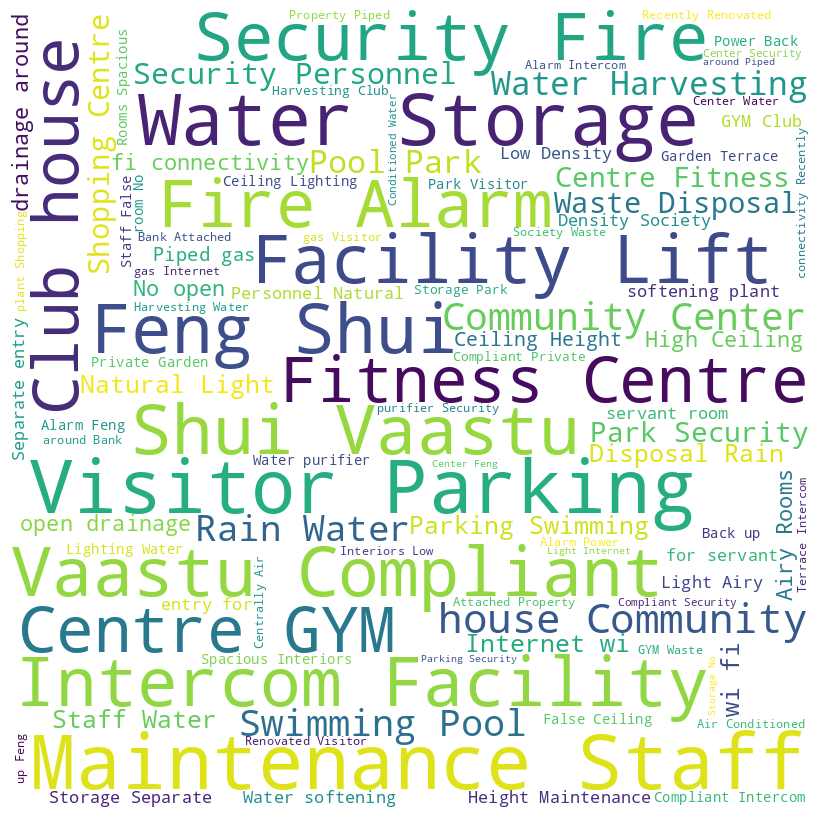

In [35]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show() # st.pyplot()

In [36]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [39]:
fig = px.scatter(df, x="price", y="built_up_area", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [40]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [41]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

<ipython-input-42-dc32b660127e>:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-42-dc32b660127e>:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

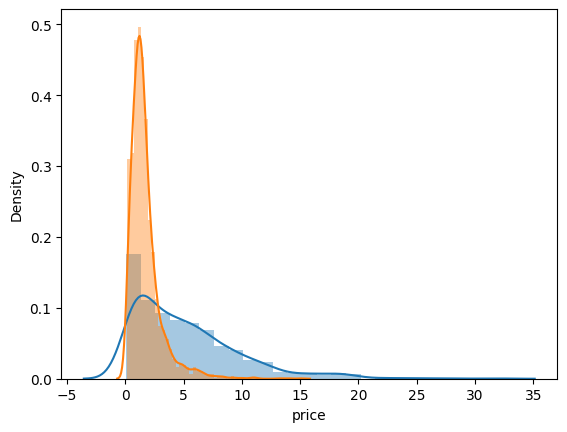

In [42]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])